<a href="https://colab.research.google.com/github/Nicholas-2305/MMA3001-Project-Nicholas-Caciolo-34988858/blob/main/NC_pork_rasher_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pork Rasher Packaging Defect Detection — Baseline Model

MMA3001 project starter notebook. This trains a YOLO **instance segmentation** model (via the `ultralytics` package) on the Pork Rasher Error (Packaging) dataset, evaluates it, and runs it on some test images.

**Classes:** `loose-meat`, `packaging-error`, `twisted-meat`, `unsealed`, `wrinkle`

### Before running
1. In Colab: **Runtime → Change runtime type → GPU** (T4 is fine).
2. Upload `Pork_Rasher_Error-Packaging-_v4i_yolo26.zip` to your Google Drive, e.g. into `MyDrive/mma3001_project/` (any folder — you set the path in Cell 3 below).
3. Run the cells in order, top to bottom.


## 1. Check GPU and install dependencies

In [1]:
!nvidia-smi


Fri Sep 25 06:02:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   54C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install -q ultralytics

import ultralytics
ultralytics.checks()


Ultralytics 8.4.162 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.4/112.6 GB disk)


## 2. Mount Google Drive and locate the dataset zip

Edit `ZIP_PATH` below to match where you uploaded the zip file in your Drive.

In [6]:
from google.colab import drive
drive.mount('/content/drive')

# EDIT THIS to the actual path of the zip file in your Google Drive
ZIP_PATH = '/content/drive/MyDrive/2026 - Third Year/Semester 2/MMA3001 - Numerical Models and Machine Learning/Project MEAT/Pork Rasher Error-Packaging-.v4i.yolo26.zip'

import os
assert os.path.exists(ZIP_PATH), f'Zip not found at {ZIP_PATH} — check the path and try again.'
print('Found zip:', ZIP_PATH)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found zip: /content/drive/MyDrive/2026 - Third Year/Semester 2/MMA3001 - Numerical Models and Machine Learning/Project MEAT/Pork Rasher Error-Packaging-.v4i.yolo26.zip


In [5]:
import glob
matches = glob.glob('/content/drive/MyDrive/**/*.zip', recursive=True)
for m in matches:
    print(m)

/content/drive/MyDrive/Ryujinx/ryujinx-1-1-1403.zip
/content/drive/MyDrive/Ryujinx/ProdKeys.net-v18.-1-0.zip
/content/drive/MyDrive/Ryujinx/Firmware 18.1.0.zip
/content/drive/MyDrive/Emulator/Citra/Games/3DS-stuff-master.zip
/content/drive/MyDrive/2024 - First Year/ENG1014/Exam /Stock Files/drive-download-20241016T072914Z-001.zip
/content/drive/MyDrive/2024 - First Year/ENG1014/Exam /Stock Files/drive-download-20241016T072935Z-001.zip
/content/drive/MyDrive/2024 - First Year/ENG1014/Exam /Stock Files/drive-download-20241016T072947Z-001.zip
/content/drive/MyDrive/2026 - Third Year/Semester 2/MMA3001 - Numerical Models and Machine Learning/Project MEAT/Pork Rasher Error-Packaging-.v4i.yolo26.zip


## 3. Unzip the dataset and fix `data.yaml` to use absolute paths

In [7]:
import zipfile, shutil

DATA_ROOT = '/content/data'
if os.path.exists(DATA_ROOT):
    shutil.rmtree(DATA_ROOT)
os.makedirs(DATA_ROOT, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(DATA_ROOT)

print('Extracted to', DATA_ROOT)
print(os.listdir(DATA_ROOT))


Extracted to /content/data
['README.roboflow.txt', 'test', 'valid', 'README.dataset.txt', 'train', 'data.yaml']


In [8]:
# The dataset's own data.yaml uses relative paths that assume it lives inside
# a split subfolder. We rewrite it here with absolute paths so training is unambiguous.

CLASS_NAMES = ['loose-meat', 'packaging-error', 'twisted-meat', 'unsealed', 'wrinkle']

data_yaml_content = f"""train: {DATA_ROOT}/train/images
val: {DATA_ROOT}/valid/images
test: {DATA_ROOT}/test/images

nc: {len(CLASS_NAMES)}
names: {CLASS_NAMES}
"""

DATA_YAML_PATH = f'{DATA_ROOT}/data_fixed.yaml'
with open(DATA_YAML_PATH, 'w') as f:
    f.write(data_yaml_content)

print(data_yaml_content)


train: /content/data/train/images
val: /content/data/valid/images
test: /content/data/test/images

nc: 5
names: ['loose-meat', 'packaging-error', 'twisted-meat', 'unsealed', 'wrinkle']



## 4. Sanity-check: visualise a few images with their annotations

This catches path/label problems before you spend time training, and doubles as a figure for your report.

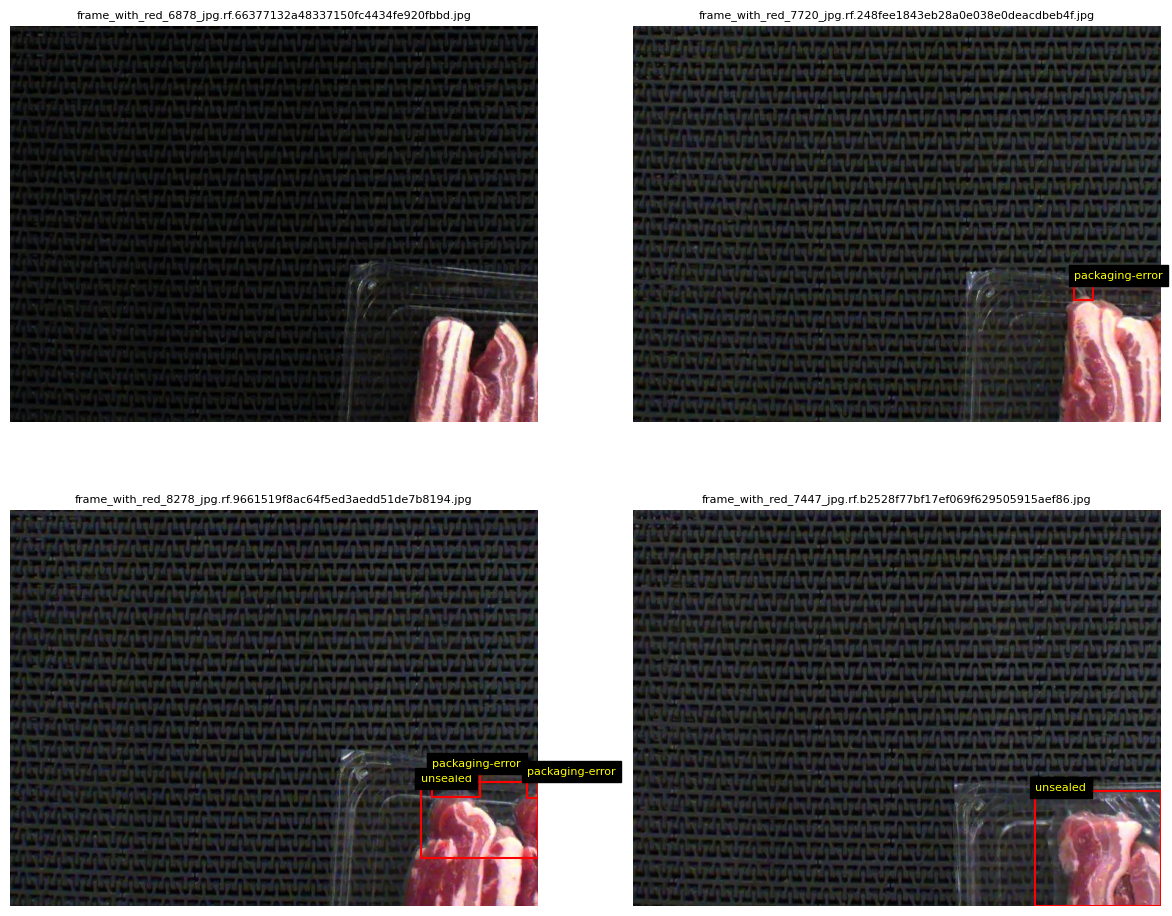

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import glob, random

def load_yolo_seg_label(label_path):
    """Read a YOLO label file.

    Each line is either a plain bounding box (class_id xc yc w h - 4 numbers,
    normalised 0-1) or a polygon (class_id x1 y1 x2 y2 ... xn yn - variable length).
    Returns a list of (class_id, [(x, y), ...]) tuples, with boxes converted
    into 4-corner polygons so both can be drawn the same way.
    """
    shapes = []
    with open(label_path) as f:
        for line in f:
            parts = line.split()
            if not parts:
                continue
            class_id = int(parts[0])
            coords = list(map(float, parts[1:]))
            if len(coords) == 4:
                xc, yc, bw, bh = coords
                x1, y1 = xc - bw / 2, yc - bh / 2
                x2, y2 = xc + bw / 2, yc + bh / 2
                points = [(x1, y1), (x2, y1), (x2, y2), (x1, y2)]
            else:
                points = list(zip(coords[0::2], coords[1::2]))
            shapes.append((class_id, points))
    return shapes

image_dir = f'{DATA_ROOT}/train/images'
label_dir = f'{DATA_ROOT}/train/labels'
sample_images = random.sample(glob.glob(f'{image_dir}/*.jpg'), 4)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, img_path in zip(axes.flat, sample_images):
    img = Image.open(img_path)
    w, h = img.size
    ax.imshow(img)
    label_path = os.path.join(label_dir, os.path.basename(img_path).replace('.jpg', '.txt'))
    if os.path.exists(label_path):
        for class_id, points in load_yolo_seg_label(label_path):
            px = [x * w for x, y in points]
            py = [y * h for x, y in points]
            ax.add_patch(patches.Polygon(list(zip(px, py)), closed=True, fill=False, edgecolor='red', linewidth=1.5))
            ax.text(px[0], py[0], CLASS_NAMES[class_id], color='yellow', fontsize=8, backgroundcolor='black')
    ax.set_title(os.path.basename(img_path), fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.savefig('/content/sanity_check.png', dpi=150)
plt.show()


## 5. Train a baseline model

`yolov8n-seg.pt` (nano) is the smallest/fastest segmentation model — good for a first run. `epochs` and `imgsz` are kept modest here so this finishes in a reasonable time on a free Colab GPU; increase them once you confirm everything works.

In [12]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')  # pretrained nano segmentation model, fine-tuned on our data

train_results = model.train(
    data=DATA_YAML_PATH,
    epochs=100,
    imgsz=640,
    batch=16,
    project='/content/runs',
    name='baseline_yolov8n_detect',
    patience=15,   # stop early if validation performance plateaus
)


Ultralytics 8.4.162 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data/data_fixed.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=baseline_yolov8n_detect, nbs=64, nms=None, opse

## 6. Validate on the held-out validation set

This reports standard detection/segmentation metrics: mAP50, mAP50-95, precision and recall, per class.

In [ ]:
metrics = model.val(data=DATA_YAML_PATH, split='val')
print('mAP50 (box):', metrics.box.map50)
print('mAP50-95 (box):', metrics.box.map)
print('mAP50 (mask):', metrics.seg.map50)
print('mAP50-95 (mask):', metrics.seg.map)


## 7. Run inference on the test set and visualise predictions

The test split was never used for training or for tuning, so this is your best evidence of real-world performance. Predicted images (with boxes/masks drawn) are saved automatically.

In [ ]:
test_results = model.predict(
    source=f'{DATA_ROOT}/test/images',
    save=True,
    project='/content/runs',
    name='test_predictions',
    conf=0.25,
)

print(f'Predictions saved to: /content/runs/test_predictions')
print(f'Ran inference on {len(test_results)} test images.')


In [ ]:
# Show a few predicted images inline
pred_dir = '/content/runs/test_predictions'
pred_images = glob.glob(f'{pred_dir}/*.jpg')[:4]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, img_path in zip(axes.flat, pred_images):
    ax.imshow(Image.open(img_path))
    ax.set_title(os.path.basename(img_path), fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()


## 8. Evaluate on the test set (not just validation)

`model.val()` above used the validation split (used implicitly during training for early stopping). Run it again on the **test** split for your final reported numbers — this is the split your report should quote, since it's untouched by training decisions.

In [ ]:
test_metrics = model.val(data=DATA_YAML_PATH, split='test')
print('Test mAP50 (box):', test_metrics.box.map50)
print('Test mAP50-95 (box):', test_metrics.box.map)
print('Test mAP50 (mask):', test_metrics.seg.map50)
print('Test mAP50-95 (mask):', test_metrics.seg.map)


## Next steps (not run automatically — for you to build on)

This notebook gets you a working baseline end to end. To meet the rest of the rubric:

- **Comparison / alternative approach**: train a second model to compare against this baseline — e.g. a larger variant (`yolov8s-seg.pt`) for an accuracy-vs-speed trade-off, or a plain detection-only model (`yolov8n.pt` with bounding-box labels) to compare segmentation vs detection-only.
- **Optimisation**: try different `imgsz`, `epochs`, or `batch` values and report runtime/accuracy trade-offs; time inference per image (`model.predict(..., verbose=True)` reports this).
- **Validation depth**: build a confusion matrix (ultralytics saves one automatically under the run folder), and manually inspect a sample of failure cases with a defined pass/fail criterion.
- **Documentation**: docstring the helper functions above (e.g. `load_yolo_seg_label`) properly, and move reusable code out of the notebook into `.py` modules in your GitHub repo for the code-quality marks.
